In [8]:
%load_ext autoreload
%autoreload 2

## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 3
#### ***Part B: Autoencoder - Next Digit Reconstruction***

This notebook implements various autoencoder architectures for MNIST next digit reconstruction and compares them with PCA. A simple CNN digit classifier is applied to reconstructed images.

In [9]:
import numpy as np
import time
import tensorflow as tf
import matplotlib.pyplot as plt
import dataProccessing as dp
import nextDigit as nd
from keras import layers, Model, models
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten, BatchNormalization, Dropout, Concatenate
from keras.optimizers import Adam

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

In [15]:
import importlib
importlib.reload(nd)

<module 'nextDigit' from 'c:\\Users\\theod\\OneDrive - Αριστοτέλειο Πανεπιστήμιο Θεσσαλονίκης\\Επιφάνεια εργασίας\\9ο εξάμηνο\\Νευρωνικά Δίκτυα\\Εργασίες\\Neural-Networks\\Exercise_3\\nextDigit.py'>

**MNIST dataset preparation**

In [16]:
# Load and normalize MNIST dataset
x_train, y_train, x_test, y_test = dp.load_mnist()

# Flatten MNIST images
x_train, x_test = dp.flatten_mnist(x_train, x_test)

# Create next digit dataset
train_inputs, train_outputs, test_inputs, test_outputs = nd.next_digit_dataset(x_train, y_train, x_test, y_test)

# Get one example of each digit from the test set
test_indices = nd.get_stratified_next_digit_samples(y_test)

Loading and Normalizing MNIST Dataset
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Flattening MNIST images
Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)

Creating Next Digit Dataset
Creating training pairs:
Digit 0 -> 1: 5923 pairs
Digit 1 -> 2: 5958 pairs
Digit 2 -> 3: 5958 pairs
Digit 3 -> 4: 5842 pairs
Digit 4 -> 5: 5421 pairs
Digit 5 -> 6: 5421 pairs
Digit 6 -> 7: 5918 pairs
Digit 7 -> 8: 5851 pairs
Digit 8 -> 9: 5851 pairs
Digit 9 -> 0: 5923 pairs

Creating test pairs:
Digit 0 -> 1: 980 pairs
Digit 1 -> 2: 1032 pairs
Digit 2 -> 3: 1010 pairs
Digit 3 -> 4: 982 pairs
Digit 4 -> 5: 892 pairs
Digit 5 -> 6: 892 pairs
Digit 6 -> 7: 958 pairs
Digit 7 -> 8: 974 pairs
Digit 8 -> 9: 974 pairs
Digit 9 -> 0: 980 pairs

Total training pairs: 58066
Total test pairs: 9674



#### **Model 1: Dense Next Digit Autoencoder**

Dropout layers are used to prevent overfitting. No extra metrics are being used here.


Training Next Digit Model 1...
Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0718 - val_loss: 0.0754
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0562 - val_loss: 0.0735
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0547 - val_loss: 0.0738
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0543 - val_loss: 0.0731
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0541 - val_loss: 0.0722
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0539 - val_loss: 0.0715
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0538 - val_loss: 0.0717
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0537 - val_loss: 0.0707
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0536 - val_loss: 0.0713
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0536 - val_loss: 0.0713
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0535 - val_loss: 0.0714
Epoch 12/

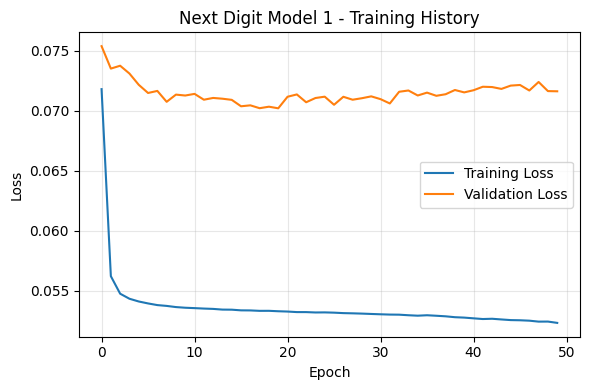

Next Digit Model 1 Final Validation Loss: 0.071625
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


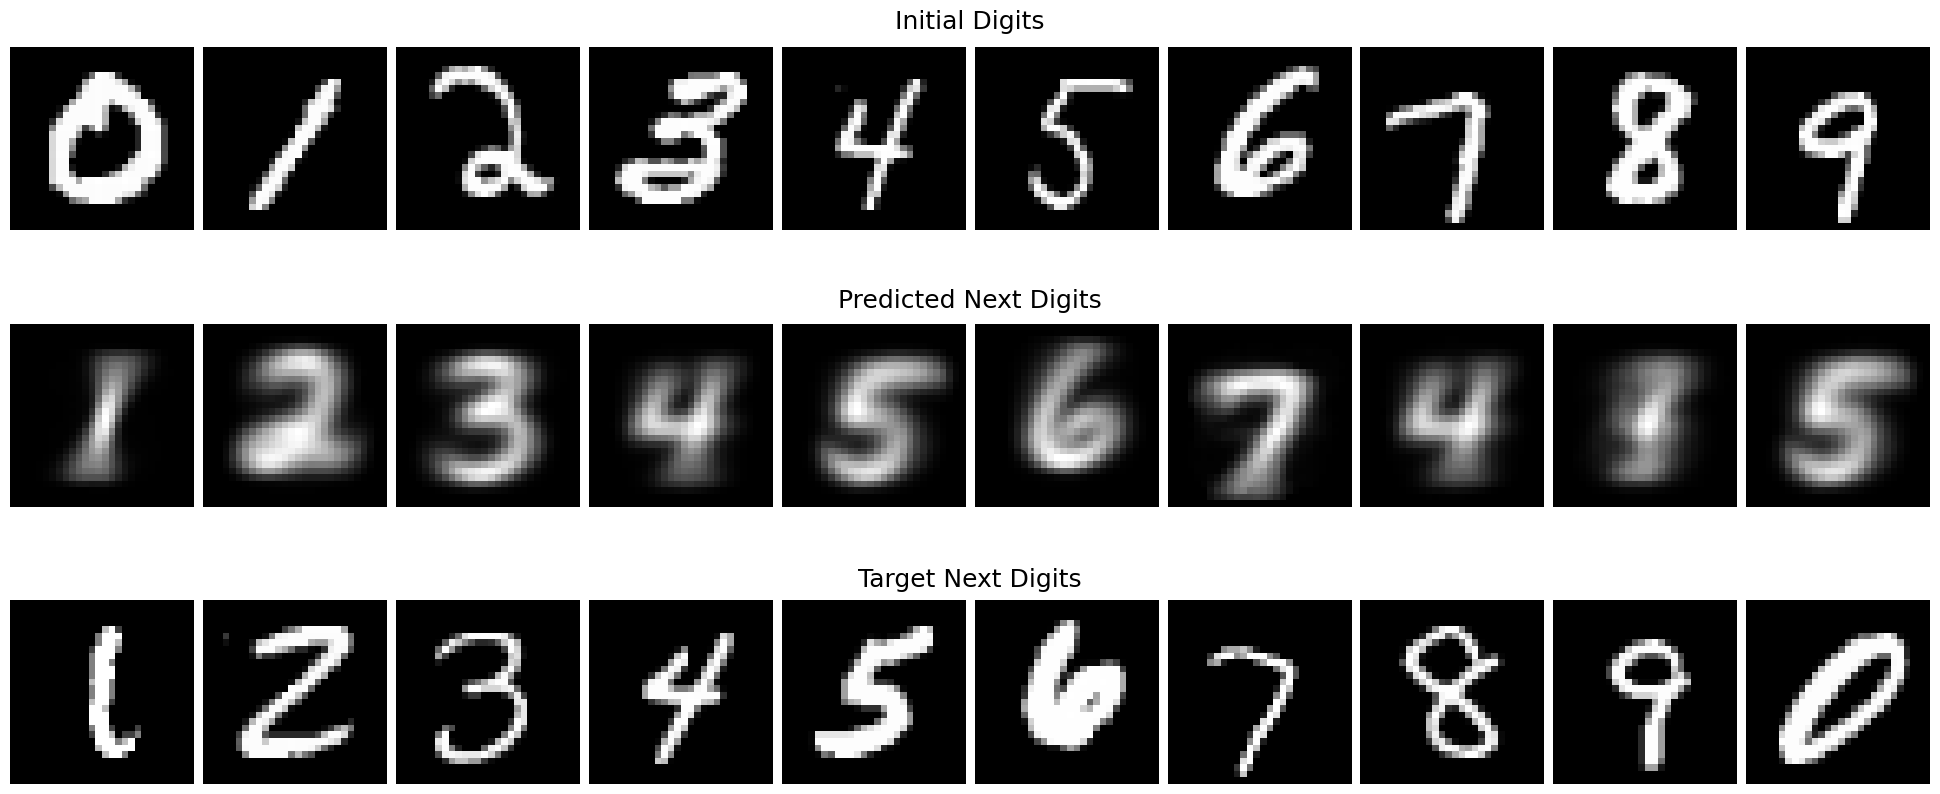

303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Next Digit Model 1 Test MSE: 0.060664


In [18]:
# Model 1: Dense architecture for next digit generation
encoding_dim = 128

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_nd1 = Model(encoder_input, latent, name='encoder_next_digit_1')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(256, activation='relu')(decoder_input)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_nd1 = Model(decoder_input, decoder_output, name='decoder_next_digit_1')

# Next Digit Autoencoder Model
autoencoder_nd1 = Model(encoder_input, decoder_nd1(encoder_nd1(encoder_input)), name='autoencoder_next_digit_1')
autoencoder_nd1.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Next Digit Model 1...")
start_time = time.time()
history_nd1 = autoencoder_nd1.fit(train_inputs, train_outputs, epochs=50,
                                batch_size=256, validation_split=0.4, verbose=1)
train_time_nd1 = time.time() - start_time
print(f"\nNext Digit Model 1 Training Time: {train_time_nd1:.2f} seconds")

# Plot history
dp.plot_history(history_nd1, "Next Digit Model 1")

# Store validation loss
val_loss_nd1 = history_nd1.history['val_loss'][-1]
print(f"Next Digit Model 1 Final Validation Loss: {val_loss_nd1:.6f}")

# Visualize predictions
predictions_nd1 = autoencoder_nd1.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd1, test_outputs[test_indices], n=10)

# Evaluate
mse_nd1 = dp.calculate_mse(test_outputs, autoencoder_nd1.predict(test_inputs))
print(f"Next Digit Model 1 Test MSE: {mse_nd1:.6f}")


#### **Model 2: Convolutional Next Digit Autoencoder**

Added Early Stopping and PSNR, SSIM metrics. No Dropout layers for now.


Training Next Digit Model 2 (CNN) using Early Stopping...

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 119s 796ms/step - loss: 0.0770 - psnr: 11.6339 - ssim: 0.1899 - val_loss: 0.0936 - val_psnr: 10.4644 - val_ssim: 0.0701
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 87s 635ms/step - loss: 0.0542 - psnr: 12.9687 - ssim: 0.2477 - val_loss: 0.0850 - val_psnr: 10.8577 - val_ssim: 0.0899
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 81s 590ms/step - loss: 0.0535 - psnr: 13.0293 - ssim: 0.2594 - val_loss: 0.0815 - val_psnr: 11.1370 - val_ssim: 0.1200
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 585ms/step - loss: 0.0533 - psnr: 13.0468 - ssim: 0.2655 - val_loss: 0.0817 - val_psnr: 11.2325 - val_ssim: 0.1420
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 597ms/step - loss: 0.0531 - psnr: 13.0619 - ssim: 0.2701 - val_loss: 0.0771 - val_psnr: 11.4511 - val_ssim: 0.1644
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 583ms/step - loss: 0.0529 - psnr: 13.0829 - ssim: 0.2747 - val_loss: 0.0745 - val_psnr: 11.5514 - va

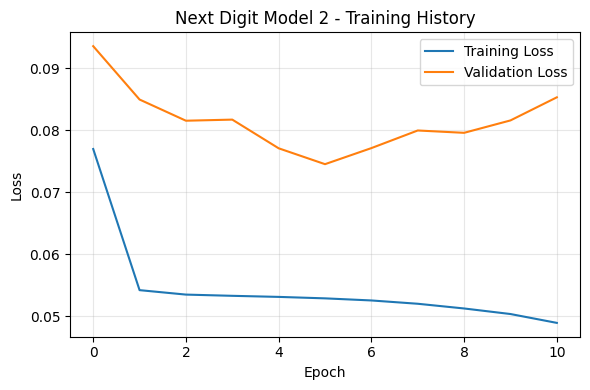

Next Digit Model 2 Final Validation Loss: 0.085324
Next Digit Model 2 Final Validation PSNR: 13.466555
Next Digit Model 2 Final Validation SSIM: 0.328759
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step


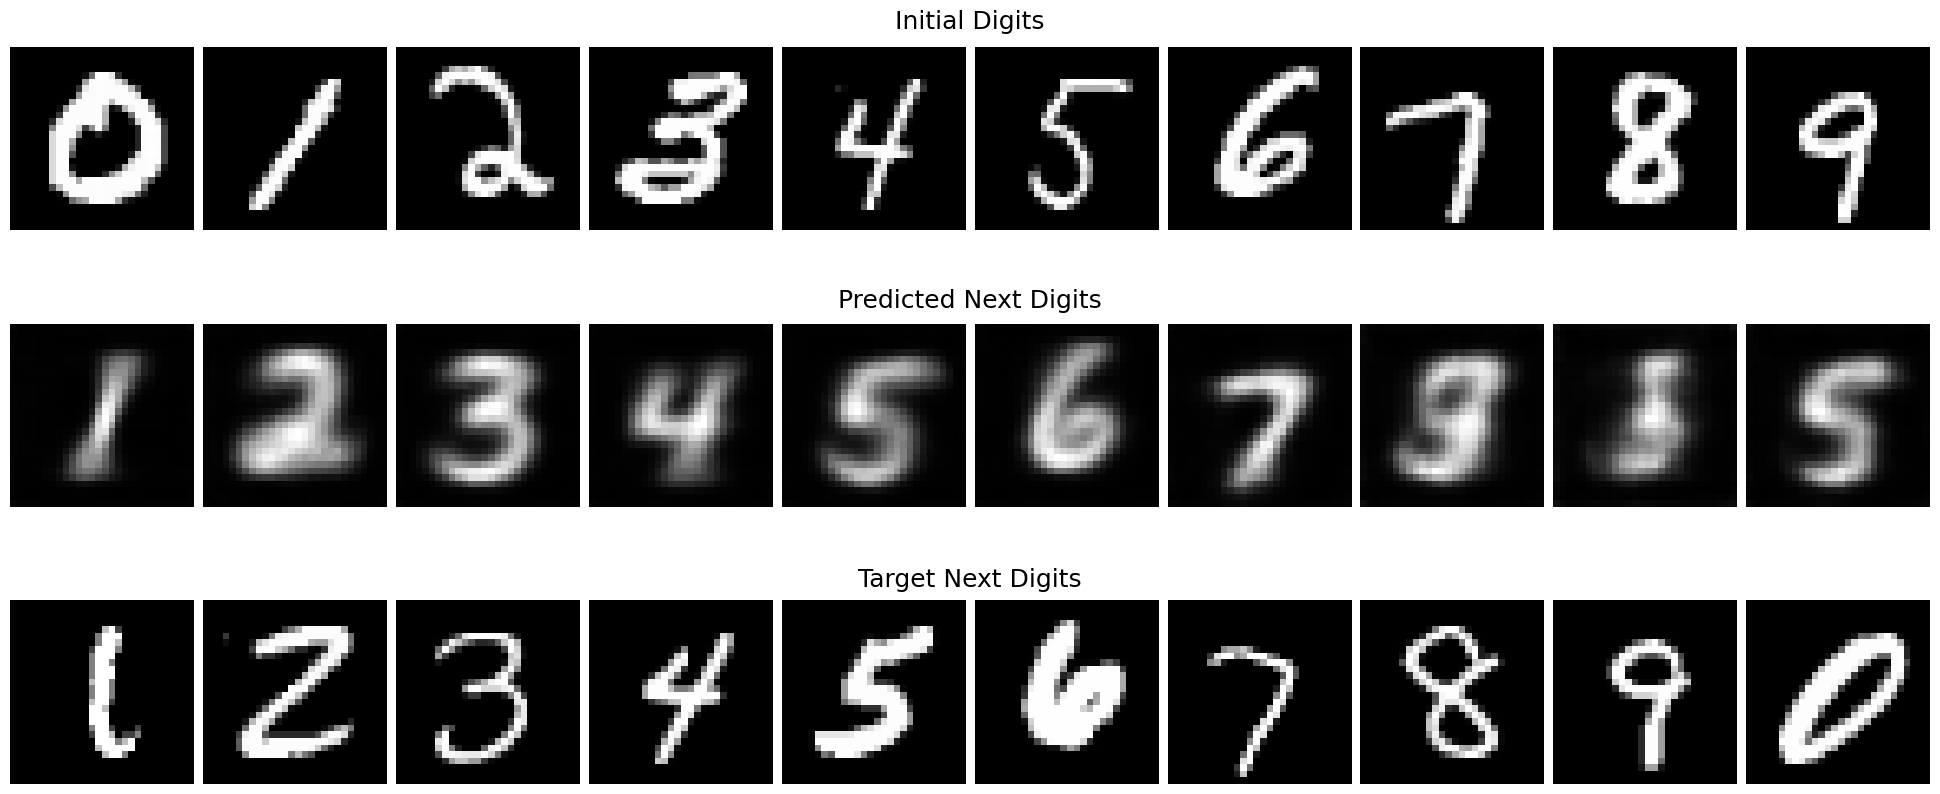

303/303 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Next Digit Model 2 Test MSE: 0.062399


In [19]:
# Model 2: Convolutional architecture for next digit generation
encoding_dim = 512

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x = Reshape((28, 28, 1))(encoder_input)

# Encoder: Conv2D + BatchNormalization + MaxPooling
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# Flatten and create latent representation
x = Flatten()(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_nd2 = Model(encoder_input, latent, name='encoder_next_digit_2')

# Decoder: Dense → Reshape
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_input)
x = Reshape((7, 7, 128))(x)

# Decoder: Conv2D + BatchNormalization + UpSampling
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = Flatten()(x)

decoder_nd2 = Model(decoder_input, decoder_output, name='decoder_next_digit_2')

# Next Digit Autoencoder
autoencoder_nd2 = Model(encoder_input, decoder_nd2(encoder_nd2(encoder_input)), 
                        name='autoencoder_next_digit_2_CNN')

# Compile with metrics
autoencoder_nd2.compile(optimizer=Adam(learning_rate=0.001), loss='mse', 
                        metrics=[dp.psnr, dp.ssim])

# Early Stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                 # Stop if no improvement for 5 epochs
    restore_best_weights=True,  # Restore weights from best epoch
    verbose=1
)

# Train with early stopping
print("\nTraining Next Digit Model 2 (CNN) using Early Stopping...\n")
start_time = time.time()
history_nd2 = autoencoder_nd2.fit(train_inputs, train_outputs, epochs=50, batch_size=256,
                                   validation_split=0.4, callbacks=[early_stop], verbose=1)
train_time_nd2 = time.time() - start_time
print(f"\nNext Digit Model 2 Training Time: {train_time_nd2:.2f} seconds")
print(f"Next Digit Model 2 Stopped at Epoch: {len(history_nd2.history['loss'])}")

# Plot history
dp.plot_history(history_nd2, "Next Digit Model 2")

# Store validation loss and metrics
val_loss_nd2 = history_nd2.history['val_loss'][-1]
val_psnr_nd2 = history_nd2.history['psnr'][-1]
val_ssim_nd2 = history_nd2.history['ssim'][-1]
print(f"Next Digit Model 2 Final Validation Loss: {val_loss_nd2:.6f}")
print(f"Next Digit Model 2 Final Validation PSNR: {val_psnr_nd2:.6f}")
print(f"Next Digit Model 2 Final Validation SSIM: {val_ssim_nd2:.6f}")

# Visualize predictions
predictions_nd2 = autoencoder_nd2.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd2, 
                                test_outputs[test_indices], n=10)

# Evaluate
mse_nd2 = dp.calculate_mse(test_outputs, autoencoder_nd2.predict(test_inputs))
print(f"Next Digit Model 2 Test MSE: {mse_nd2:.6f}")


#### **Model 3: Advanced Convolutional Next Digit Autoencoder**

Convolutional Next Digit Autoencoder with Dropout layers in order to reduce overfitting. Reduced learning rate, increased Early Stopping patience and used Binary Crossentropy loss instead of MSE.


Training Next Digit Model 3 (CNN) with Dropout...

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 100s 680ms/step - loss: 0.4776 - psnr: 9.0148 - ssim: 0.1280 - val_loss: 0.4118 - val_psnr: 9.8282 - val_ssim: 0.0634
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 664ms/step - loss: 0.3114 - psnr: 11.4684 - ssim: 0.1862 - val_loss: 0.3572 - val_psnr: 10.4275 - val_ssim: 0.0898
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 665ms/step - loss: 0.2757 - psnr: 12.1520 - ssim: 0.2064 - val_loss: 0.3265 - val_psnr: 10.8433 - val_ssim: 0.1046
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 665ms/step - loss: 0.2571 - psnr: 12.4793 - ssim: 0.2176 - val_loss: 0.3008 - val_psnr: 11.3186 - val_ssim: 0.1305
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 666ms/step - loss: 0.2462 - psnr: 12.6479 - ssim: 0.2255 - val_loss: 0.2879 - val_psnr: 11.5870 - val_ssim: 0.1497
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 668ms/step - loss: 0.2395 - psnr: 12.7407 - ssim: 0.2322 - val_loss: 0.2828 - val_psnr: 11.6855 - val_ssim: 0.

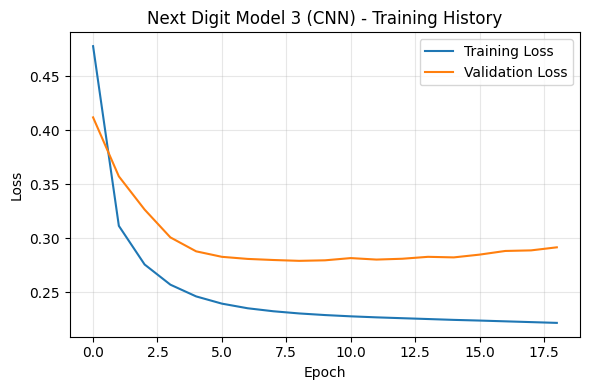

Next Digit Model 3 Final Validation Loss: 0.291596
Next Digit Model 3 Final Validation PSNR: 12.997940
Next Digit Model 3 Final Validation SSIM: 0.279821
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step


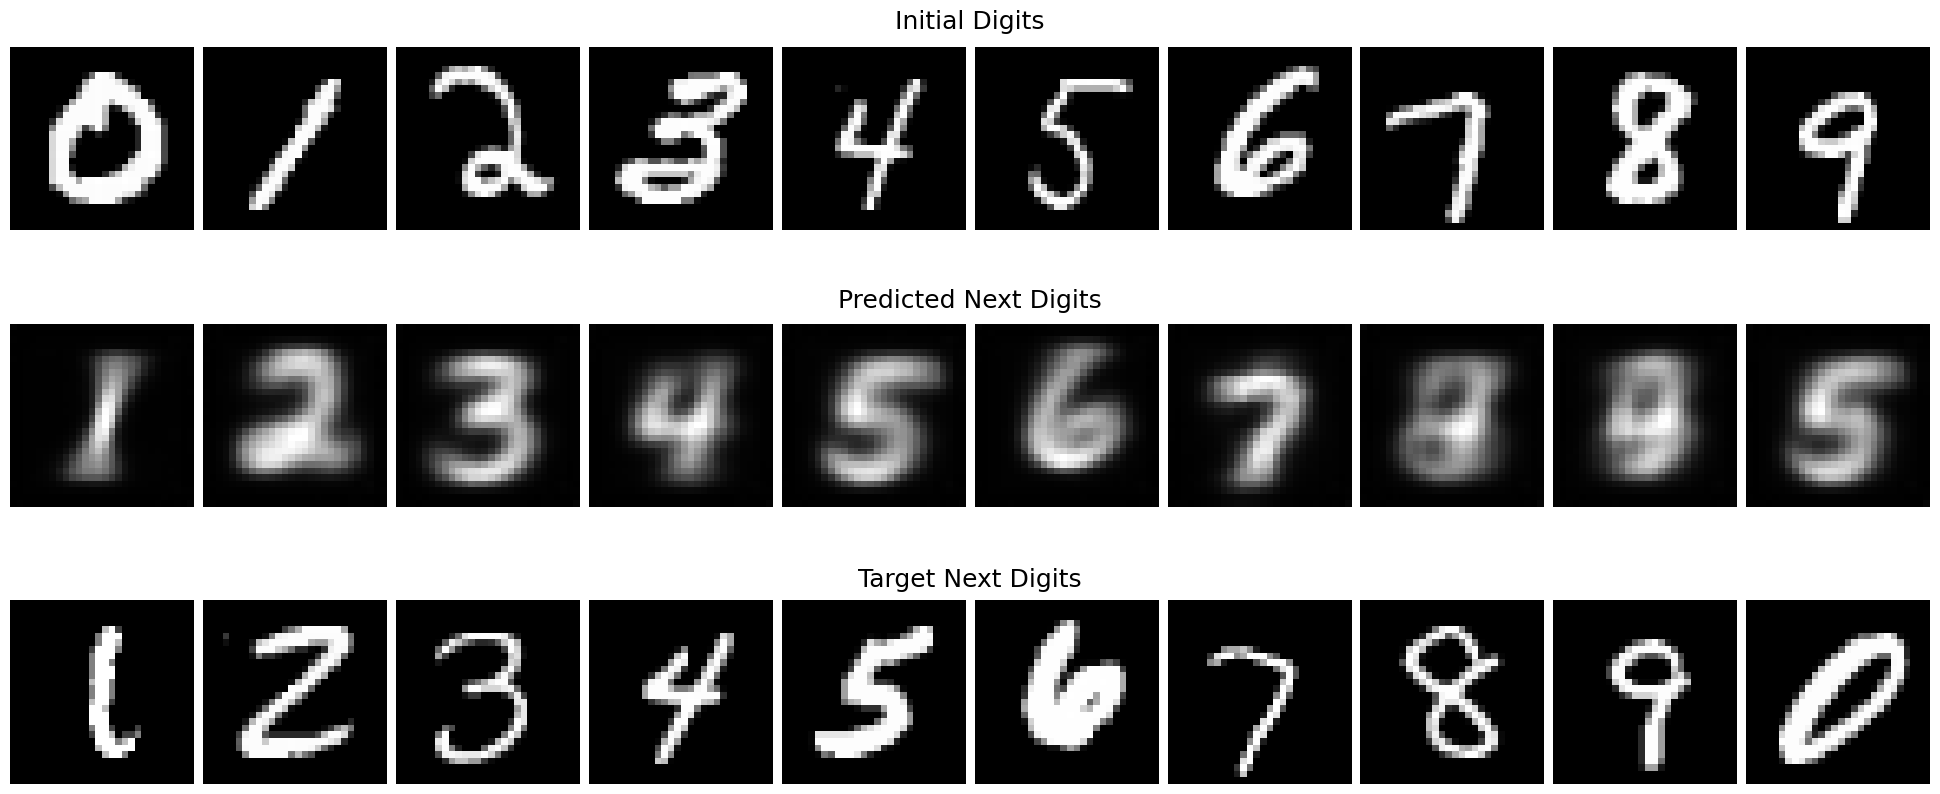

303/303 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step
Next Digit Model 3 Test MSE: 0.059952


In [20]:
# Model 3: Convolutional architecture for next digit generation with Dropout
encoding_dim = 512

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x = Reshape((28, 28, 1))(encoder_input)

# Encoder: Conv2D + BatchNormalization + Dropout + MaxPooling
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Flatten and create latent representation
x = Flatten()(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_nd3 = Model(encoder_input, latent, name='encoder_next_digit_3')

# Decoder: Dense → Reshape
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_input)
x = Reshape((7, 7, 128))(x)

# Decoder: Conv2D + BatchNormalization + Dropout + UpSampling
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = Flatten()(x)

decoder_nd3 = Model(decoder_input, decoder_output, name='decoder_next_digit_3')

# Next Digit Autoencoder
autoencoder_nd3 = Model(encoder_input, decoder_nd3(encoder_nd3(encoder_input)), 
                        name='autoencoder_next_digit_3_CNN')

# Compile with binary cross-entropy and reduced learning rate
autoencoder_nd3.compile(
    optimizer=Adam(learning_rate=0.0001),  # 10x smaller: 0.001 → 0.0001
    loss='binary_crossentropy',            # Changed from 'mse' to 'binary_crossentropy'
    metrics=[dp.psnr, dp.ssim]
)

# Early Stopping callback with increased patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,                # Increased from 5 → 10
    restore_best_weights=True,
    verbose=1
)

# Train with early stopping
print("\nTraining Next Digit Model 3 (CNN) with Dropout...\n")
start_time = time.time()
history_nd3 = autoencoder_nd3.fit(train_inputs, train_outputs, epochs=50, batch_size=256,
                                  validation_split=0.4, callbacks=[early_stop], verbose=1)
train_time_nd3 = time.time() - start_time
print(f"\nNext Digit Model 3 Training Time: {train_time_nd3:.2f} seconds")
print(f"Next Digit Model 3 Stopped at Epoch: {len(history_nd3.history['loss'])}")

# Plot history
dp.plot_history(history_nd3, "Next Digit Model 3 (CNN)")

# Store validation loss and metrics
val_loss_nd3 = history_nd3.history['val_loss'][-1]
val_psnr_nd3 = history_nd3.history['psnr'][-1]
val_ssim_nd3 = history_nd3.history['ssim'][-1]
print(f"Next Digit Model 3 Final Validation Loss: {val_loss_nd3:.6f}")
print(f"Next Digit Model 3 Final Validation PSNR: {val_psnr_nd3:.6f}")
print(f"Next Digit Model 3 Final Validation SSIM: {val_ssim_nd3:.6f}")

# Visualize predictions
predictions_nd3 = autoencoder_nd3.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd3, 
                                test_outputs[test_indices], n=10)

# Evaluate
mse_nd3 = dp.calculate_mse(test_outputs, autoencoder_nd3.predict(test_inputs))
print(f"Next Digit Model 3 Test MSE: {mse_nd3:.6f}")

#### **Model 4: U-Net Style Next Digit Autoencoder**

Advanced architecture with skip connections and learning rate scheduler.


Training Next Digit Model 4 (U-Net) with Skip Connections...

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 116s 802ms/step - loss: 0.6151 - psnr: 7.3665 - ssim: 0.0545 - val_loss: 0.4988 - val_psnr: 8.5734 - val_ssim: 0.0037 - learning_rate: 1.0000e-04
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 94s 683ms/step - loss: 0.4317 - psnr: 9.3654 - ssim: 0.0863 - val_loss: 0.8814 - val_psnr: 5.4521 - val_ssim: 0.0283 - learning_rate: 1.0000e-04
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 678ms/step - loss: 0.3513 - psnr: 10.6078 - ssim: 0.1097 - val_loss: 0.9592 - val_psnr: 6.0275 - val_ssim: 0.0678 - learning_rate: 1.0000e-04
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 92s 673ms/step - loss: 0.3064 - psnr: 11.3912 - ssim: 0.1277 - val_loss: 0.5992 - val_psnr: 7.9736 - val_ssim: 0.0952 - learning_rate: 1.0000e-04
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 667ms/step - loss: 0.2814 - psnr: 11.8388 - ssim: 0.1411 - val_loss: 0.4044 - val_psnr: 9.6462 - val_ssim: 0.1193 - learning_rate: 1.0000e-04
Epoch 6/

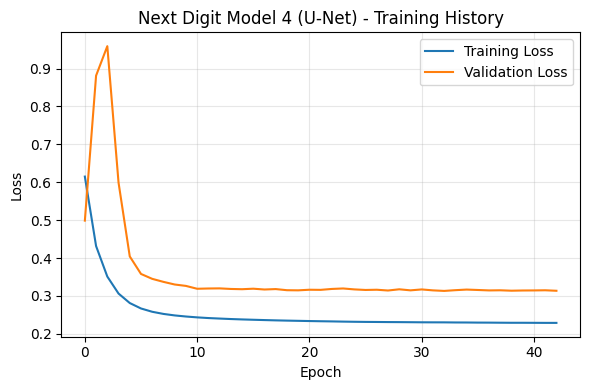


Next Digit Model 4 Final Validation Loss: 0.313784
Next Digit Model 4 Final Validation PSNR: 12.796196
Next Digit Model 4 Final Validation SSIM: 0.240281
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step


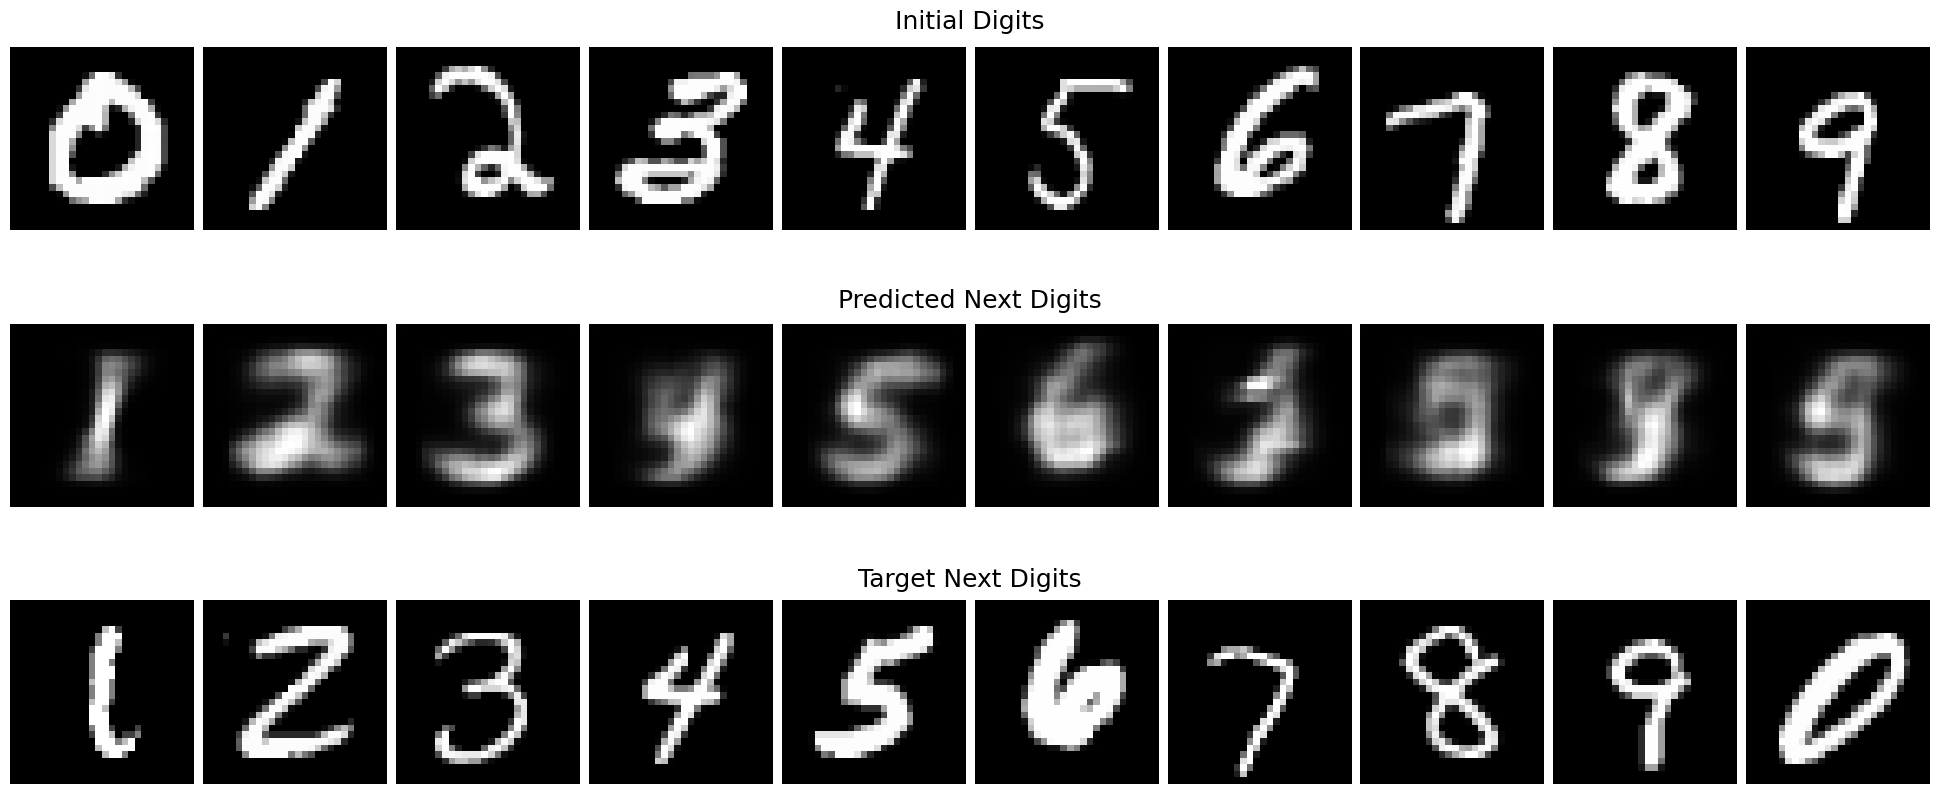

303/303 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Next Digit Model 4 Test MSE: 0.065706


In [21]:
# Model 4: U-Net style architecture with Skip Connections

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x1 = layers.Reshape((28, 28, 1))(encoder_input)

# Encoder (Contracting Path)
x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.2)(x1)
x = MaxPooling2D((2, 2), padding='same')(x1)

x2 = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.2)(x2)
x = MaxPooling2D((2, 2), padding='same')(x2)

x3 = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.2)(x3)

# Decoder (Expansive Path with Skip Connections)
x = UpSampling2D((2, 2))(x3)
skip1 = Concatenate()([x, x2])  # Skip connection from encoder block 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(skip1)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = UpSampling2D((2, 2))(x)
skip2 = Concatenate()([x, x1])  # Skip connection from encoder block 1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(skip2)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = layers.Flatten()(x)

# U-Net Autoencoder
autoencoder_nd4 = Model(encoder_input, decoder_output, name='autoencoder_next_digit_4_UNet')

# Compile with binary cross-entropy and reduced learning rate
autoencoder_nd4.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[dp.psnr, dp.ssim]
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Learning Rate Scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # Reduce LR by half
    patience=5,              # Wait 5 epochs before reducing
    min_lr=0.00001,          # Don't go below 1e-5
    verbose=1
)

# Train with both Early Stopping and LR Scheduler
print("\nTraining Next Digit Model 4 (U-Net) with Skip Connections...\n")
start_time = time.time()
history_nd4 = autoencoder_nd4.fit(train_inputs, train_outputs, epochs=50, batch_size=256,
                                validation_split=0.4, callbacks=[early_stop, reduce_lr], verbose=1)
train_time_nd4 = time.time() - start_time
print(f"\nNext Digit Model 4 Training Time: {train_time_nd4:.2f} seconds")
print(f"Next Digit Model 4 Stopped at Epoch: {len(history_nd4.history['loss'])}")

# Plot history
dp.plot_history(history_nd4, "Next Digit Model 4 (U-Net)")

# Store validation metrics
val_loss_nd4 = history_nd4.history['val_loss'][-1]
val_psnr_nd4 = history_nd4.history['psnr'][-1]
val_ssim_nd4 = history_nd4.history['ssim'][-1]
print(f"\nNext Digit Model 4 Final Validation Loss: {val_loss_nd4:.6f}")
print(f"Next Digit Model 4 Final Validation PSNR: {val_psnr_nd4:.6f}")
print(f"Next Digit Model 4 Final Validation SSIM: {val_ssim_nd4:.6f}")

# Visualize predictions (sample every 1000th)
predictions_nd4 = autoencoder_nd4.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd4, 
                                test_outputs[test_indices], n=10)

# Evaluate
mse_nd4 = dp.calculate_mse(test_outputs, autoencoder_nd4.predict(test_inputs))
print(f"Next Digit Model 4 Test MSE: {mse_nd4:.6f}")


## Evaluate Next Digit Models with Classifier
Check if the generated digits are correctly classified.

In [ ]:
# Evaluate Model 1 (Dense)
print("Evaluating Next Digit Model 1 (Dense):")
mse_nd1_final, acc_nd1 = evaluate_next_digit_quality(
    next_digit_model_1, test_inputs_flat, test_outputs_flat, classifier
)

# Evaluate Model 2 (Conv)
print("\nEvaluating Next Digit Model 2 (Conv):")
mse_nd2_final, acc_nd2 = evaluate_next_digit_quality(
    next_digit_model_2, test_inputs_cnn, test_outputs_cnn.reshape(-1, 784), classifier
)

# Evaluate Model 3 (U-Net)
print("\nEvaluating Next Digit Model 3 (U-Net):")
mse_nd3_final, acc_nd3 = evaluate_next_digit_quality(
    next_digit_model_3, test_inputs_cnn, test_outputs_cnn.reshape(-1, 784), classifier
)

## Next Digit Models Comparison

In [ ]:
# Collect all next digit results
results_nd = [
    ("Model 1: Dense", mse_nd1, acc_nd1, autoencoder_nd1.count_params(), train_time_nd1),
    ("Model 2: Conv", mse_nd2, acc_nd2, autoencoder_nd2.count_params(), train_time_nd2),
    ("Model 3: Conv (BCE)", mse_nd3, acc_nd3, autoencoder_nd3.count_params(), train_time_nd3),
    ("Model 4: U-Net", mse_nd4, acc_nd4, autoencoder_nd4.count_params(), train_time_nd4)
]

print("\n" + "="*90)
print("NEXT DIGIT MODELS COMPARISON")
print("="*90)
print(f"{'Model':<25} {'MSE':<15} {'Accuracy':<15} {'Parameters':<20}")
print("-"*90)

for model_name, mse, acc, params in results_nd:
    acc_str = f"{acc:.2f}%" if acc is not None else "N/A"
    print(f"{model_name:<25} {mse:<15.6f} {acc_str:<15} {params:<20,}")

print("="*90 + "\n")

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# MSE comparison
model_names = [r[0] for r in results_nd]
mse_values = [r[1] for r in results_nd]
acc_values = [r[2] for r in results_nd]

ax1.bar(model_names, mse_values, color='coral', alpha=0.7)
ax1.set_ylabel('MSE')
ax1.set_title('Reconstruction Error (MSE)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Accuracy comparison
ax2.bar(model_names, acc_values, color='lightgreen', alpha=0.7)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Classification Accuracy of Generated Digits')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 100])

plt.tight_layout()
plt.show()

## Generate More Examples
Test the best model on specific digit transitions.